<a href="https://colab.research.google.com/github/szmygielski/lecture1/blob/main/PUM4_regresja_todo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

zaczytanie niezbędnych bibliotek

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score
from sklearn.preprocessing import StandardScaler

zaczytaj dane dotyczace sprzedazy

In [2]:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Corrected dataset handle and file name
dataset_handle = "rkiattisak/salaly-prediction-for-beginer"
file_name_in_dataset = "Salary Data.csv"

# Load the latest version
# Using dataset_load as suggested by the DeprecationWarning
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  dataset_handle,
  file_name_in_dataset
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

100%|██████████| 18.9k/18.9k [00:00<00:00, 29.3MB/s]

First 5 records:     Age  Gender Education Level          Job Title  Years of Experience  \
0  32.0    Male      Bachelor's  Software Engineer                  5.0   
1  28.0  Female        Master's       Data Analyst                  3.0   
2  45.0    Male             PhD     Senior Manager                 15.0   
3  36.0  Female      Bachelor's    Sales Associate                  7.0   
4  52.0    Male        Master's           Director                 20.0   

     Salary  
0   90000.0  
1   65000.0  
2  150000.0  
3   60000.0  
4  200000.0  


preprocessing

1.   sprawdż typy danych
2.   zmien etykiedy na zmienne liczbowe
3. w przypadku brakujacych danych uzupelnij (w przypadku etykiet) najczesciej wystepującą wartością lub średnią wartością



In [21]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

df.shape
df.info()

le = LabelEncoder()

for column in ['Gender', 'Job Title', 'Education Level']:
  if column in df.columns:
    df[column] = le.fit_transform(df[column])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  375 non-null    float64
 1   Gender               375 non-null    int64  
 2   Education Level      375 non-null    int64  
 3   Job Title            375 non-null    int64  
 4   Years of Experience  375 non-null    float64
 5   Salary               375 non-null    float64
dtypes: float64(3), int64(3)
memory usage: 17.7 KB


Podziel zbiór danych na testowy i treningowy w stosunku 30/70

In [22]:
from sklearn.model_selection import train_test_split

df.dropna(inplace=True)
y = df['Salary']
x = df.drop('Salary', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Training set size: 262
Testing set size: 113


Stworz model regresji liniowej korzystajac z parametrów domyślnych
Przykład dokumentacji: https://scikit-learn.org/stable/auto_examples/linear_model/plot_ols.html#sphx-glr-auto-examples-linear-model-plot-ols-py

In [24]:
regressor = LinearRegression().fit(X_train, y_train)
y_pred = regressor.predict(X_test)

ocen model na zbiorze testowym za pomocą miar: średni błąd kwadratowy, średni błąd absolutny, wynik wyjaśnionej wariancji

In [26]:
print(f"Średni błąd kwadratowy: {mean_squared_error(y_test, y_pred)}")
print(f"Średni błąd absolutny: {mean_absolute_error(y_test, y_pred)}")
print(f"Wynik wyjaśnionej wariancji: {explained_variance_score(y_test, y_pred)}")


Średni błąd kwadratowy: 247847820.9042658
Średni błąd absolutny: 11004.396751660437
Wynik wyjaśnionej wariancji: 0.884713440400604


spróbuj poprawić model, zacznij od danych, sprawdz korelacje, znormalizuj

In [29]:
#sprawdzenie korelacji
correlation_matrix = df.corr()
print(correlation_matrix)
# usuwa zmienna Age mocno skorelwoana z Years of Experience
#X_train.drop('Age', axis = 1, inplace = True)
#X_test.drop('Age', axis = 1, inplace = True)

                          Age    Gender  Education Level  Job Title  \
Age                  1.000000 -0.019865         0.546020   0.232477   
Gender              -0.019865  1.000000         0.008677   0.146383   
Education Level      0.546020  0.008677         1.000000   0.113495   
Job Title            0.232477  0.146383         0.113495   1.000000   
Years of Experience  0.979128  0.002818         0.573355   0.248352   
Salary               0.922335  0.069498         0.650507   0.211788   

                     Years of Experience    Salary  
Age                             0.979128  0.922335  
Gender                          0.002818  0.069498  
Education Level                 0.573355  0.650507  
Job Title                       0.248352  0.211788  
Years of Experience             1.000000  0.930338  
Salary                          0.930338  1.000000  


In [32]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

regressorLscaled = LinearRegression().fit(X_train, y_train)
print(f"Współczynniki: {regressorLscaled.coef_}")
y_pred

Współczynniki: [ 2695.14621588  9602.26898851  -634.64950981 39707.45077527]


array([171455.39872752,  94523.3161155 , 132458.45824734,  81736.67751435,
       159605.08519243, 188215.05602799, 160983.15822948, 101577.19467674,
        57304.89663755,  99100.86476359, 139844.41160817, 160896.89640968,
        49805.90040386,  87838.71058095,  63070.14660306, 160175.83575635,
        64640.8360135 ,  48141.09830575,  76673.20986426,  96667.85091136,
       124922.77488724, 106102.97506133, 163389.46092287,  62586.09715044,
        87810.91014626,  50439.22175368, 179327.43069955, 143093.81681783,
       155724.91096611, 149920.03866187,  40342.5365277 , 123994.89722141,
        53817.52206027, 151762.72320445,  87381.00769222,  18996.04945339,
       182871.39711257,  49885.743982  ,  37019.83709049,  58282.46232466,
        45187.69122485,  85914.42818161, 175708.58027692, 165839.88356362,
        44177.08585222, 153447.47486937, 121742.92910556,  48247.77259679,
        48052.27209475,  38201.53584484, 100715.5844064 ,  79977.64554286,
        75174.00634672, 1

Zbuduj model regresji odpornej i przetestuj jego predykcje

In [33]:
regressorLscaled = LinearRegression().fit(X_train, y_train)
print(f"Współczynniki: {regressorLscaled.coef_}")
y_predLscaled = regressorLscaled.predict(X_test)
print(f"Średni błąd kwadratowy: {mean_squared_error(y_test, y_predLscaled)}")
print(f"Średni błąd absolutny: {mean_absolute_error(y_test, y_predLscaled)}")
print(f"Wynik wyjaśnionej wariancji: {explained_variance_score(y_test, y_predLscaled)}")



Współczynniki: [ 2695.14621588  9602.26898851  -634.64950981 39707.45077527]
Średni błąd kwadratowy: 241797521.8185071
Średni błąd absolutny: 11017.50899174796
Wynik wyjaśnionej wariancji: 0.8872480733529419


Wykreś przewidziane i faktyczne wartości obu modeli (przykład w dokumentacji: https://scikit-learn.org/stable/auto_examples/ensemble/plot_voting_regressor.html#sphx-glr-auto-examples-ensemble-plot-voting-regressor-py)

Zmodyfikuj kod, zeby zwizualizować wynik lepszego z modeli

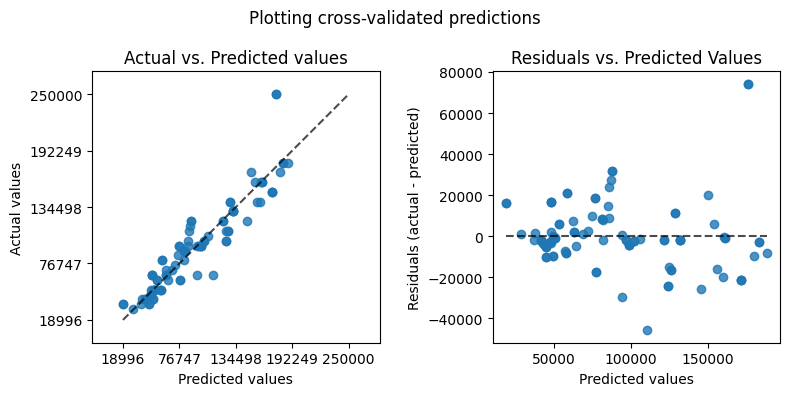

In [34]:
import matplotlib.pyplot as plt

from sklearn.metrics import PredictionErrorDisplay

fig, axs = plt.subplots(ncols=2, figsize=(8, 4))
PredictionErrorDisplay.from_predictions(
    y_test,
    y_pred=y_pred,
    kind="actual_vs_predicted",
    subsample=100,
    ax=axs[0],
    random_state=0,
)
axs[0].set_title("Actual vs. Predicted values")
PredictionErrorDisplay.from_predictions(
    y_test,
    y_pred=y_pred,
    kind="residual_vs_predicted",
    subsample=100,
    ax=axs[1],
    random_state=0,
)
axs[1].set_title("Residuals vs. Predicted Values")
fig.suptitle("Plotting cross-validated predictions")
plt.tight_layout()
plt.show()